# day 34 | 251117 M

## herein 

We are going to 

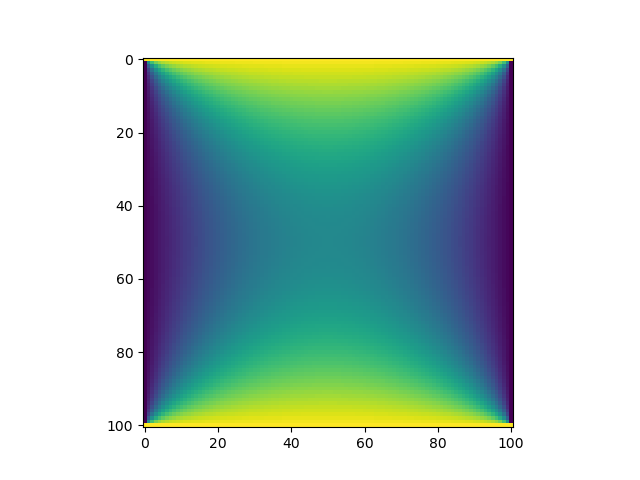

In [2]:
M = 100 # grid size
V = 1.0 # voltage

target = 2**-16

phi = np.zeros([M+1, M+1], float)
phi[0, :] = V
phi[-1, :] = V

phiprime = np.empty([M+1,M+1], float)

delta = 1.0

while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            if i == 0 or i == M or j==0 or j==M:
                phiprime[i,j] = phi[i,j]
            else:
                phiprime[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4
    delta = np.max(np.abs(phi-phiprime))
    phi, phiprime = phiprime, phi

fig2, ax2 = plt.subplots()
ax2.imshow(phi)

first we will change this by updating phi rather than calculating phiprime. this is a subtle change but a slight speed up since two of the four values that we are averaging are "new" values.

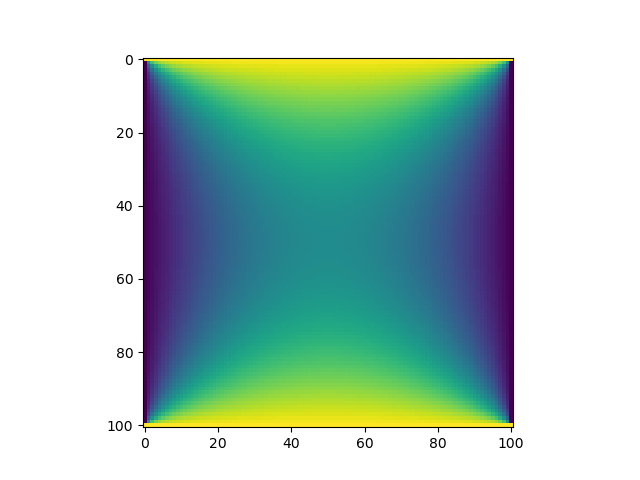

In [3]:
M = 100 # grid size
V = 1.0 # voltage

target = 2**-16

phi = np.zeros([M+1, M+1], float)
phi[0, :] = V
phi[-1, :] = V

dphi = np.empty([M+1,M+1], float)

delta = 1.0

while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            # first we look for the boundary
            if i == 0 or i == M or j==0 or j==M:
                phi[i,j] = phi[i,j]
                dphi[i,j] = 0
            else:
                dphi[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4 - phi[i,j]
                phi[i,j] = phi[i,j] + dphi[i,j]
    delta = np.max(np.abs(dphi))

fig2, ax2 = plt.subplots()
ax2.imshow(phi)

now we are going to apply another technique know as overrelaxation.

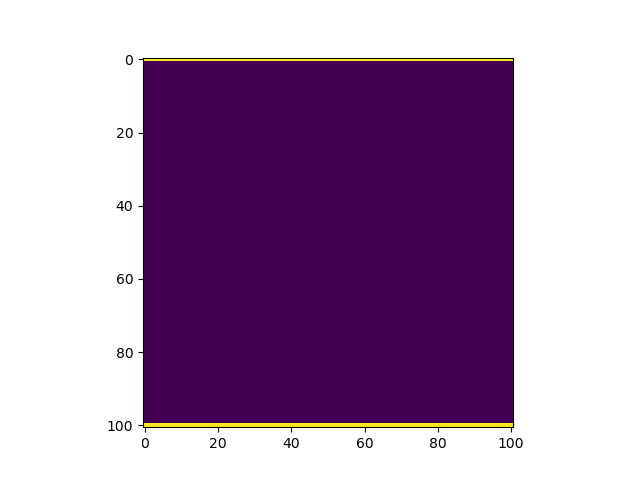

In [4]:
M = 100 # grid size
V = 1.0 # voltage

target = 2**-16

phi = np.zeros([M+1, M+1], float)
phi[0, :] = V
phi[-1, :] = V

dphi = np.empty([M+1,M+1], float)

omega = 0.9 # this is the parameter that we can change to speed this up.

delta = 1.0

fig, ax = plt.subplots()
ax.imshow(phi)

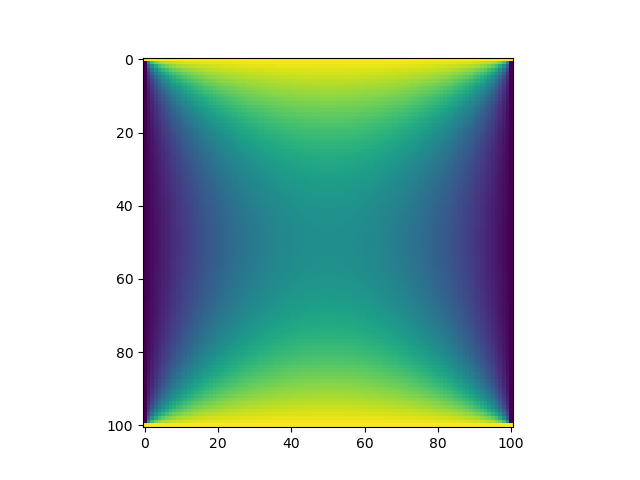

In [5]:
while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            # first we look for the boundary
            if i == 0 or i == M or j==0 or j==M:
                phi[i,j] = phi[i,j]
                dphi[i,j] = 0
            else:
                dphi[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4 - phi[i,j]
                phi[i,j] = phi[i,j] + (1+omega)*(dphi[i,j])
    delta = np.max(np.abs(dphi))

fig2, ax2 = plt.subplots()
ax2.imshow(phi)